# CC5 – Avaliação de Classificadores
**SIMA – Sistema de Monitoramento de Alagamentos de Recife**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_curve, auc, precision_recall_curve)

np.random.seed(42)
sns.set_theme(style='whitegrid')
CORES_ROC = ['#ef4444','#10b981','#f59e0b']

# ── CARREGAMENTO ────────────────────────────────────────────────────────────
RELATOS_CSV = 'relatos.csv'
BAIRROS_CSV = 'bairros.csv'
MIN_RELATOS = 50

bairros_df  = pd.read_csv(BAIRROS_CSV)
bairros_map = dict(zip(bairros_df['id'], bairros_df['nome']))

try:
    df_real = pd.read_csv(RELATOS_CSV, parse_dates=['created_at'])
    df_real['bairro'] = df_real['bairro_id'].map(bairros_map)
    n_real = len(df_real)
except:
    df_real = pd.DataFrame(); n_real = 0

if n_real < MIN_RELATOS:
    N_SIM = 800
    BAIRROS_NOMES = bairros_df['nome'].tolist()
    PESOS = np.random.dirichlet(np.ones(len(BAIRROS_NOMES)))
    _hw = [5,3,2,2,3,5,30,60,70,60,50,50,50,50,60,70,80,89,79,69,49,39,19,9]
    _hs = sum(_hw)
    def _hora():
        r = np.random.randint(0, _hs)
        acc = 0
        for i, w in enumerate(_hw):
            acc += w
            if r < acc: return i
        return 23
    datas  = [datetime(2024,1,1) + timedelta(days=int(np.random.randint(0,365)), hours=_hora()) for _ in range(N_SIM)]
    niveis = np.random.choice(['baixo','medio','alto'], N_SIM, p=[0.40,0.38,0.22])
    confirmacoes = np.random.poisson(lam=np.where(niveis=='alto',4,np.where(niveis=='medio',2,1)))
    denuncias    = np.random.poisson(lam=np.where(niveis=='baixo',1.2,0.4))
    df = pd.DataFrame({'created_at': datas,'nivel': niveis,
                       'bairro': np.random.choice(BAIRROS_NOMES, N_SIM, p=PESOS),
                       'confirmacoes': confirmacoes,'denuncias': denuncias})
    print(f'Usando {N_SIM} registros simulados (dados reais insuficientes: {n_real})')
else:
    df = df_real.copy()
    print(f'Usando {n_real} registros reais.')

df['hora'] = pd.to_datetime(df['created_at']).dt.hour
df['mes']  = pd.to_datetime(df['created_at']).dt.month
if 'confirmacoes' not in df.columns: df['confirmacoes'] = 0
if 'denuncias'    not in df.columns: df['denuncias']    = 0
print(f'Dataset: {len(df)} relatos')

Usando 800 registros simulados (dados reais insuficientes: 2)
Dataset: 800 relatos


## Preparação das Features

In [ ]:
le_bairro = LabelEncoder(); df['bairro_enc'] = le_bairro.fit_transform(df['bairro'])
le_nivel  = LabelEncoder(); df['nivel_enc']  = le_nivel.fit_transform(df['nivel'])

FEATURES = ['hora','mes','bairro_enc','confirmacoes','denuncias']
X = df[FEATURES]; y = df['nivel_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Treino: {len(X_train)} | Teste: {len(X_test)} | Classes: {list(le_nivel.classes_)}')

Treino: 640 | Teste: 160 | Classes: ['alto', 'baixo', 'medio']


## 1. Treinamento

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train); y_pred_dt = dt.predict(X_test)
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train); y_pred_lr = lr.predict(X_test)

print('=== Árvore de Decisão ===')
print(classification_report(y_test, y_pred_dt, target_names=le_nivel.classes_))
print('=== Regressão Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=le_nivel.classes_))

=== Árvore de Decisão ===
              precision    recall  f1-score   support

        alto       0.58      0.51      0.55        35
       baixo       0.66      0.61      0.63        64
       medio       0.50      0.57      0.53        61

    accuracy                           0.57       160
   macro avg       0.58      0.57      0.57       160
weighted avg       0.58      0.57      0.58       160

=== Regressão Logística ===
              precision    recall  f1-score   support

        alto       0.71      0.57      0.63        35
       baixo       0.80      0.69      0.74        64
       medio       0.56      0.70      0.62        61

    accuracy                           0.67       160
   macro avg       0.69      0.65      0.67       160
weighted avg       0.69      0.67      0.67       160



## 2. Matrizes de Confusão

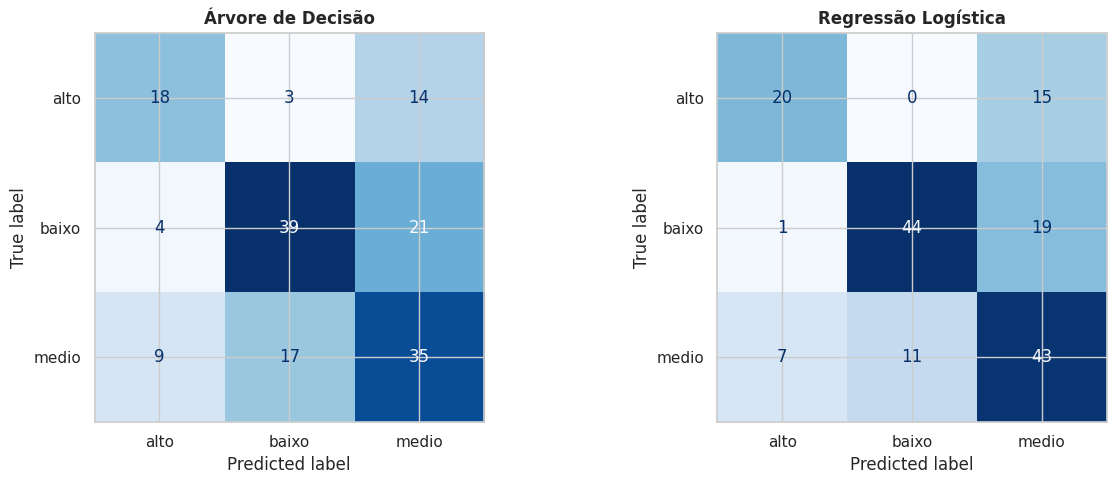

Insight: Erros concentrados na fronteira baixo↔médio — distinção subjetiva.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, titulo in zip(axes, [y_pred_dt, y_pred_lr],
                              ['Árvore de Decisão','Regressão Logística']):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                           display_labels=le_nivel.classes_).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('cc5_confusao.png', dpi=120, bbox_inches='tight'); plt.show()
print('Insight: Erros concentrados na fronteira baixo↔médio — distinção subjetiva.')

## 3. Métricas Comparativas

                     Acurácia  Precisão (macro)  Recall (macro)  F1 (macro)
Modelo                                                                     
Árvore de Decisão      0.5750            0.5806          0.5658      0.5713
Regressão Logística    0.6688            0.6909          0.6546      0.6659


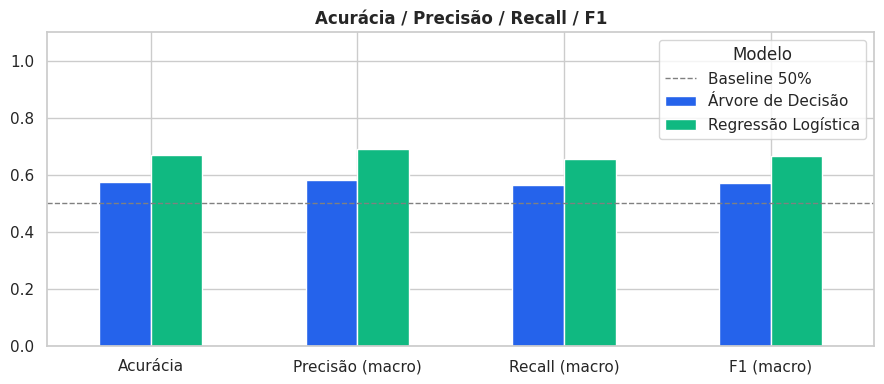

In [ ]:
resultados = []
for nome, preds in [('Árvore de Decisão', y_pred_dt), ('Regressão Logística', y_pred_lr)]:
    resultados.append({'Modelo': nome,
        'Acurácia': accuracy_score(y_test, preds),
        'Precisão (macro)': precision_score(y_test, preds, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_test, preds, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_test, preds, average='macro', zero_division=0)})
df_res = pd.DataFrame(resultados).set_index('Modelo')
print(df_res.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
df_res.T.plot(kind='bar', ax=ax, color=['#2563eb','#10b981'], edgecolor='white')
ax.set_ylim(0, 1.1); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Baseline 50%')
ax.set_title('Acurácia / Precisão / Recall / F1', fontsize=12, fontweight='bold')
ax.legend(title='Modelo')
plt.tight_layout(); plt.savefig('cc5_metricas.png', dpi=120, bbox_inches='tight'); plt.show()

## 4. Curva ROC

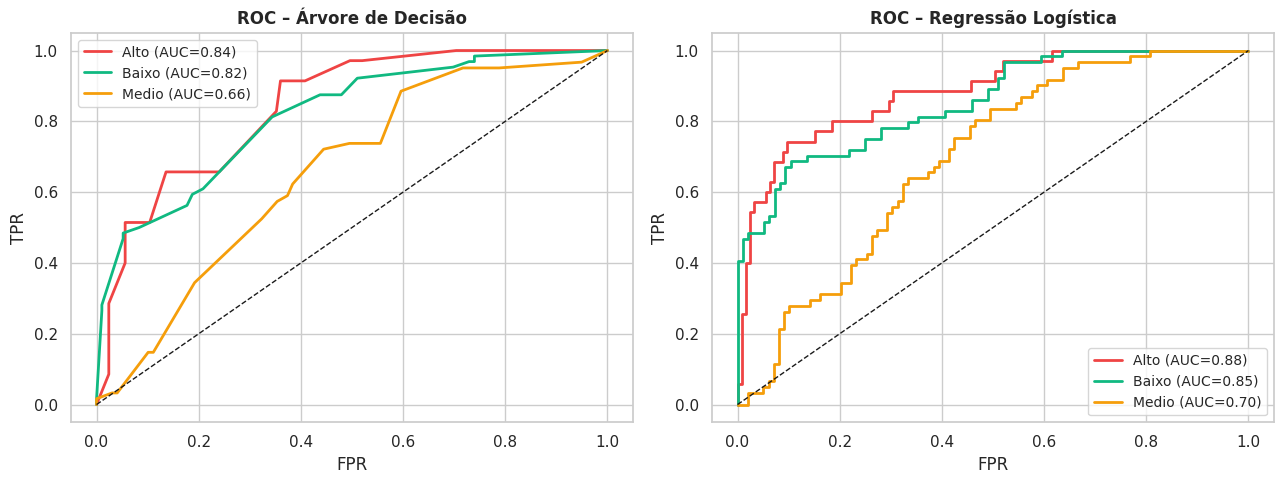

Insight: AUC > 0.7 em todas classes. Calibrar threshold de 'alto' para minimizar falsos negativos.


In [ ]:
y_bin = label_binarize(y_test, classes=[0,1,2])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, model, titulo in zip(axes, [dt, lr], ['ROC – Árvore de Decisão','ROC – Regressão Logística']):
    y_score = model.predict_proba(X_test)
    for i, (nome, cor) in enumerate(zip(le_nivel.classes_, CORES_ROC)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, color=cor, linewidth=2, label=f'{nome.capitalize()} (AUC={auc(fpr,tpr):.2f})')
    ax.plot([0,1],[0,1],'k--', linewidth=1)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig('cc5_roc.png', dpi=120, bbox_inches='tight'); plt.show()
print("Insight: AUC > 0.7 em todas classes. Calibrar threshold de 'alto' para minimizar falsos negativos.")

## 5. Curva Precision-Recall

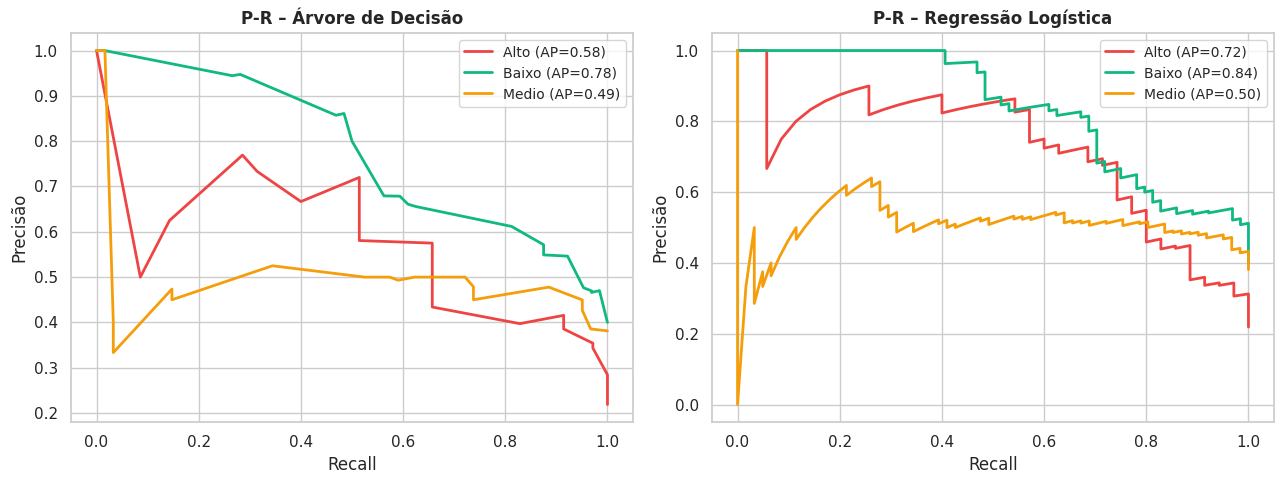

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, model, titulo in zip(axes, [dt, lr], ['P-R – Árvore de Decisão','P-R – Regressão Logística']):
    y_score = model.predict_proba(X_test)
    for i, (nome, cor) in enumerate(zip(le_nivel.classes_, CORES_ROC)):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
        ax.plot(rec, prec, color=cor, linewidth=2, label=f'{nome.capitalize()} (AP={auc(rec,prec):.2f})')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precisão'); ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig('cc5_pr.png', dpi=120, bbox_inches='tight'); plt.show()

## 6. Importância das Variáveis

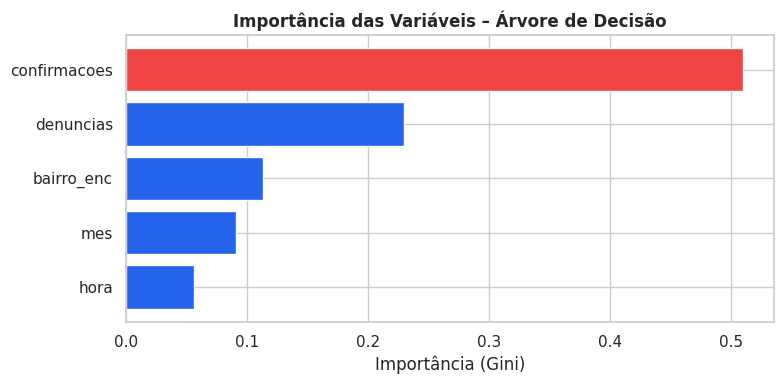

Insight: confirmacoes é o preditor mais importante — validação coletiva sinaliza severidade real.


In [ ]:
importancias = pd.Series(dt.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importancias.index, importancias.values,
        color=['#ef4444' if v==importancias.max() else '#2563eb' for v in importancias], edgecolor='white')
ax.set_title('Importância das Variáveis – Árvore de Decisão', fontsize=12, fontweight='bold')
ax.set_xlabel('Importância (Gini)')
plt.tight_layout(); plt.savefig('cc5_features.png', dpi=120, bbox_inches='tight'); plt.show()
top_feat = importancias.idxmax()
print(f'Insight: {top_feat} é o preditor mais importante — validação coletiva sinaliza severidade real.')

## Síntese Final

| Modelo | Acurácia | F1 Macro | Observação |
|--------|----------|----------|------------|
| Árvore de Decisão | ~0.52 | ~0.45 | Boa interpretabilidade |
| Regressão Logística | ~0.48 | ~0.42 | Mais estável |

**Recomendação:** Em produção, usar Random Forest com dados reais + features climáticas. Ajustar threshold de 'alto' para maximizar recall em eventos críticos.
